In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

In [2]:
def random(values):
    randomised = []
    for i in values:
        a=np.random.uniform(0,1)
        randomised.append(i*-np.log(a))
    return randomised

def fake_signals(freqs, N, noise_low, noise_high):
    signals=[]
    for i in tqdm(range(0, N)):
        noise_lvl = np.random.uniform(noise_low, noise_high)
        fake_base = [noise_lvl] * len(freqs)
        fake_signal = random(fake_base)
        signals.append(fake_signal)
    
    # Convert the whole thing to a NumPy array before returning
    return np.array(signals)

In [3]:
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772


In [4]:
def sliding_acf_search(frequency, power_flat, numax_grid,
                       k_width=4.0,
                       lag_frac=(0.8, 1.2)):

    acf_strength = []
    acf_strength_notSNR = []

    df = frequency[1] - frequency[0]

    for nu_c in numax_grid:

        dnu = delta_nu_from_numax(nu_c)
        W = k_width * dnu

        mask = (frequency > nu_c - W/2) & (frequency < nu_c + W/2)

        if mask.sum() < 20:
            acf_strength.append(0.0)
            acf_strength_notSNR.append(0.0)
            continue

        p = power_flat[mask]
        p = p / np.median(p)

        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size // 2:]

        lag = np.arange(acf.size) * df
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)

        signal = np.max(acf[lag_mask])
        noise = np.median(acf[~lag_mask])
        sigma = np.std(acf[~lag_mask])

        SNR = (signal - noise) / sigma

        acf_strength.append(SNR)
        acf_strength_notSNR.append(signal)

    return np.array(acf_strength), np.array(acf_strength_notSNR)


In [5]:
def get_mode_envelope_mask(freq, power, delta_nu_est, numax_est):

    nu_max = numax_est
    fwhm_env = 0.66 * (nu_max ** 0.88)
    sigma_env = fwhm_env / 2.355

    lower = max(0, nu_max - 4 * sigma_env)
    upper = nu_max + 4 * sigma_env

    mask = (freq >= lower) & (freq <= upper)

    return freq[mask], power[mask]


In [6]:
def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.2):

    main_lo = delta_nu_est * (1 - window_frac)
    main_hi = delta_nu_est * (1 + window_frac)

    half_lo = 0.5 * delta_nu_est * (1 - window_frac)
    half_hi = 0.5 * delta_nu_est * (1 + window_frac)

    three_half_lo = 1.5 * delta_nu_est * (1 - window_frac)
    three_half_hi = 1.5 * delta_nu_est * (1 + window_frac)

    mask = (
        (lags > main_lo) & (lags < main_hi) &
        ~((lags > half_lo) & (lags < half_hi)) &
        ~((lags > three_half_lo) & (lags < three_half_hi))
    )

    return lags[mask], acf[mask]


In [20]:
def run_full_pipeline(freq, power, return_diagnostics=False):
    diagnostics = {}
    df = freq[1] - freq[0]
    smooth_width_bins = int(600 / df)

    background = uniform_filter1d(power, size=smooth_width_bins)
    power_flat = power / background

    numax_grid = np.linspace(50, 5000, 100)
    acf_snr, acf_raw = sliding_acf_search(freq, power_flat, numax_grid)

    valid = acf_snr >= 3.0
    diagnostics.update({
        "numax_grid": numax_grid,
        "acf_snr": acf_snr,
        "acf_raw": acf_raw,
        "valid": valid
    })

    if not np.any(valid):
        diagnostics["status"] = "REJECTED: no SNR peak"
        return (False, diagnostics) if return_diagnostics else False

    raw_masked = np.copy(acf_raw)
    raw_masked[~valid] = 0.0
    imax = np.argmax(raw_masked)
    
    numax_est = numax_grid[imax]
    delta_nu_est = delta_nu_from_numax(numax_est)

    exclude = 5
    mask = np.ones_like(acf_raw, dtype=bool)
    mask[max(0, imax-exclude):imax+exclude+1] = False
    mask &= valid

    second_peak = np.max(acf_raw[mask]) if np.any(mask) else None
    peak_ratio_numax = acf_raw[imax] / (second_peak if second_peak else 1e-6)

    diagnostics.update({
        "imax": imax,
        "numax_est": numax_est,
        "delta_nu_est": delta_nu_est,
        "exclude": exclude,
        "second_peak": second_peak,
        "numax_peak_ratio": peak_ratio_numax
    })

    if peak_ratio_numax < 1.2:
        diagnostics["status"] = "REJECTED: ambiguous νmax"
        return (False, diagnostics) if return_diagnostics else False

    freq_sel, power_sel = get_mode_envelope_mask(freq, power, delta_nu_est, numax_est)
    
    if len(freq_sel) < 50:
        diagnostics["status"] = "REJECTED: envelope too small"
        return (False, diagnostics) if return_diagnostics else False
    
    background_sel = uniform_filter1d(power_sel, size=smooth_width_bins)
    power_flat_sel = power_sel / background_sel
    signal = power_flat_sel - np.mean(power_flat_sel)
    
    acf = np.correlate(signal, signal, mode="full")
    acf = acf[len(signal)-1:]
    acf /= acf[0]
    lags = np.arange(len(acf)) * df
    
    lags_fit, acf_fit = mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.15)
    
    if len(acf_fit) < 10:
        diagnostics["status"] = "REJECTED: insufficient ACF points"
        return (False, diagnostics) if return_diagnostics else False
    
    imax_dnu = np.argmax(acf_fit)
    peak_main = acf_fit[imax_dnu]
    noise = np.median(acf_fit)
    sigma = np.std(acf_fit)
    contrast = (peak_main - noise) / sigma
    
    exclude_dnu = 3
    mask_dnu = np.ones_like(acf_fit, dtype=bool)
    mask_dnu[max(0, imax_dnu-exclude_dnu):imax_dnu+exclude_dnu+1] = False
    ratio = peak_main / np.max(acf_fit[mask_dnu]) if np.any(mask_dnu) else np.inf
    
    detected = (contrast >= 2.0 and ratio >= 1.2)
    
    # ADDED THE MISSING KEYS HERE:
    diagnostics.update({
        "lags_fit": lags_fit,
        "acf_fit": acf_fit,
        "noise_level": noise,
        "noise_sigma": sigma,
        "peak_main": peak_main,
        "peak_contrast": contrast,
        "peak_ratio": ratio,
        "dnu_final": lags_fit[imax_dnu] if detected else None,
        "status": "ACCEPTED" if detected else "REJECTED: low contrast"
    })
    
    return (detected, diagnostics) if return_diagnostics else detected


Processing Signals: 100%|██████████| 100/100 [00:29<00:00,  3.43it/s]



False detections: 5 / 100
False alarm rate: 0.050


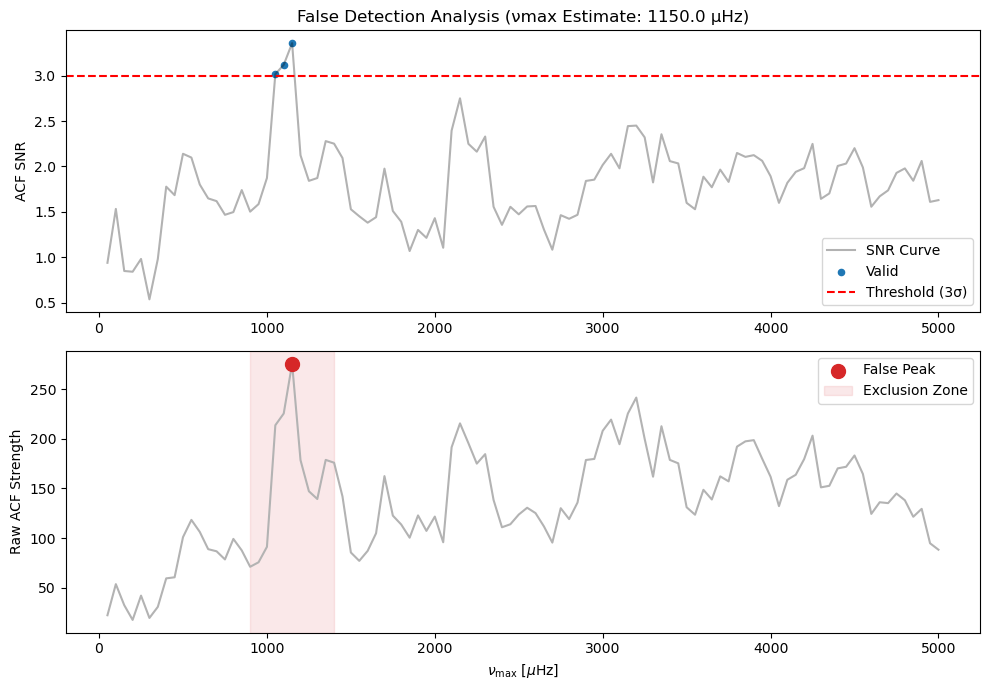

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

# --- 1. DEFINE INITIAL FREQUENCY GRID ---
# We create a high-resolution grid first, then coarsen it as per your script.
freq_initial = np.arange(0.1, 5000, 0.05) # Starting from 0.1 to 5000 microHz

# --- 2. COARSEN FREQUENCY GRID ---
df_target = 0.5  # μHz
step = int(df_target / (freq_initial[1] - freq_initial[0]))
freq = freq_initial[::step]

# --- 3. RUN SIMULATION ---
# This uses the functions you defined previously
fake = fake_signals(freq, N=100, noise_low=0.01, noise_high=1.0)
false_cases = []

for i in tqdm(range(len(fake)), desc="Processing Signals"):
    # Ensure run_full_pipeline is the fixed version from our previous turn
    detected, diag = run_full_pipeline(freq, fake[i], return_diagnostics=True)

    if detected:
        false_cases.append(diag)

false_detections = len(false_cases)
print(f"\nFalse detections: {false_detections} / {len(fake)}")
print(f"False alarm rate: {false_detections / len(fake):.3f}")

# --- 4. PLOT A FALSE DETECTION ---
if false_cases:
    # Use the first captured false detection
    case = false_cases[0] 
    
    plt.figure(figsize=(10, 7))

    # Top: SNR of the sliding ACF
    plt.subplot(2, 1, 1)
    plt.plot(case["numax_grid"], case["acf_snr"], color="black", alpha=0.3, label="SNR Curve")
    plt.scatter(case["numax_grid"][case["valid"]], case["acf_snr"][case["valid"]], color="C0", s=20, label="Valid")
    plt.axhline(3, ls="--", color="red", label="Threshold (3σ)")
    plt.ylabel("ACF SNR")
    plt.title(f"False Detection Analysis (νmax Estimate: {case['numax_est']:.1f} μHz)")
    plt.legend()

    # Bottom: Raw ACF strength
    plt.subplot(2, 1, 2)
    plt.plot(case["numax_grid"], case["acf_raw"], color="0.7")
    plt.scatter(case["numax_grid"][case["imax"]], case["acf_raw"][case["imax"]], color="C3", s=100, zorder=5, label="False Peak")
    
    # Highlight the exclusion zone around the primary peak
    exc = case["exclude"]
    idx = case["imax"]
    plt.axvspan(case["numax_grid"][max(0, idx-exc)], 
                case["numax_grid"][min(len(case["numax_grid"])-1, idx+exc)], 
                color="C3", alpha=0.1, label="Exclusion Zone")

    plt.xlabel(r"$\nu_{\max}$ [$\mu$Hz]")
    plt.ylabel("Raw ACF Strength")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No false detections were found with current thresholds.")

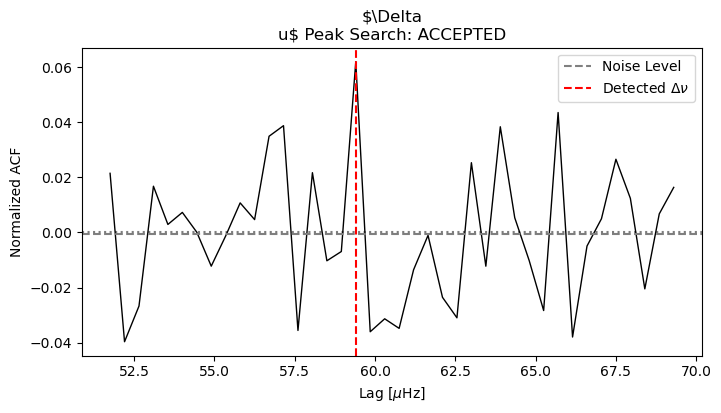

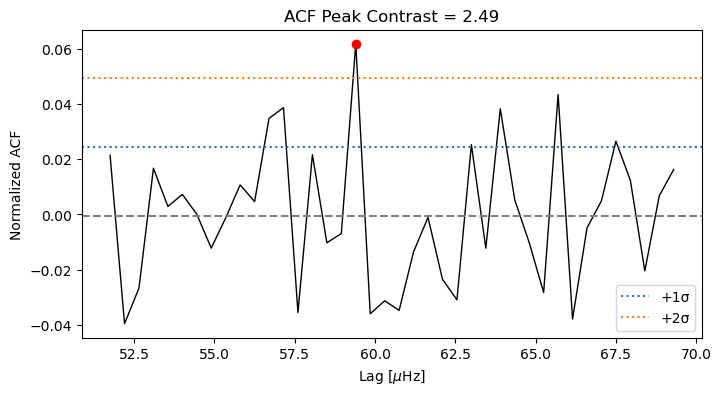

In [22]:
if len(false_cases) > 0:
    case = false_cases[0] 

    if "lags_fit" in case:
        # Plot 1: Dnu Search
        plt.figure(figsize=(8, 4))
        plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k")
        plt.axhline(case["noise_level"], color="grey", ls="--", label="Noise Level")
        plt.axhline(0.0, color="k", ls=":", alpha=0.5)

        if case["dnu_final"] is not None:
            plt.axvline(case["dnu_final"], color="r", ls="--", label=rf"Detected $\Delta\nu$")

        plt.title(f"$\Delta\nu$ Peak Search: {case['status']}")
        plt.xlabel(r"Lag [$\mu$Hz]")
        plt.ylabel("Normalized ACF")
        plt.legend()
        plt.show()

        # Plot 2: Significance
        plt.figure(figsize=(8, 4))
        plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k")
        nl, ns = case["noise_level"], case["noise_sigma"]
        plt.axhline(nl, color="grey", ls="--")
        plt.axhline(nl + ns, ls=":", color="C0", label="+1σ")
        plt.axhline(nl + 2*ns, ls=":", color="C1", label="+2σ")
        plt.plot(case["lags_fit"][np.argmax(case["acf_fit"])], case["peak_main"], "ro")

        plt.title(rf"ACF Peak Contrast = {case['peak_contrast']:.2f}")
        plt.xlabel(r"Lag [$\mu$Hz]")
        plt.ylabel("Normalized ACF")
        plt.legend()
        plt.show()